In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from western_us_biomass.make_figures import figure_settings
from western_us_biomass.make_figures.figure_settings import style_settings
from western_us_biomass import dir_info

# Figure 3
Load pre-computed data and generate the figure.

In [2]:
# Load saved figure data
save_dir = "figure_data/figure_3/"

df_timeseries = pd.read_csv(save_dir + "timeseries.csv")
years = df_timeseries["year"].values
fire_losses_west = list(df_timeseries["fire_losses_west"].values)
unburned_gains_west = list(df_timeseries["unburned_gains_west"].values)
net_changes = list(df_timeseries["net_changes"].values)

df_usfs = pd.read_csv(save_dir + "usfs_timeseries.csv")
usfs_years = df_usfs["usfs_year"].values
usfs_deltas = df_usfs["usfs_delta"].values

delta_biomass_burned = xr.open_dataset(save_dir + "delta_biomass_burned.nc")["delta_biomass_burned"]
delta_biomass_unburned = xr.open_dataset(save_dir + "delta_biomass_unburned.nc")[
    "delta_biomass_unburned"
]
forest_area_ha = xr.open_dataset(save_dir + "forest_area_ha.nc")["forest_area_ha"]

In [3]:
alpha = 0.7

/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_77937/3034969529.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)
/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_77937/3034969529.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


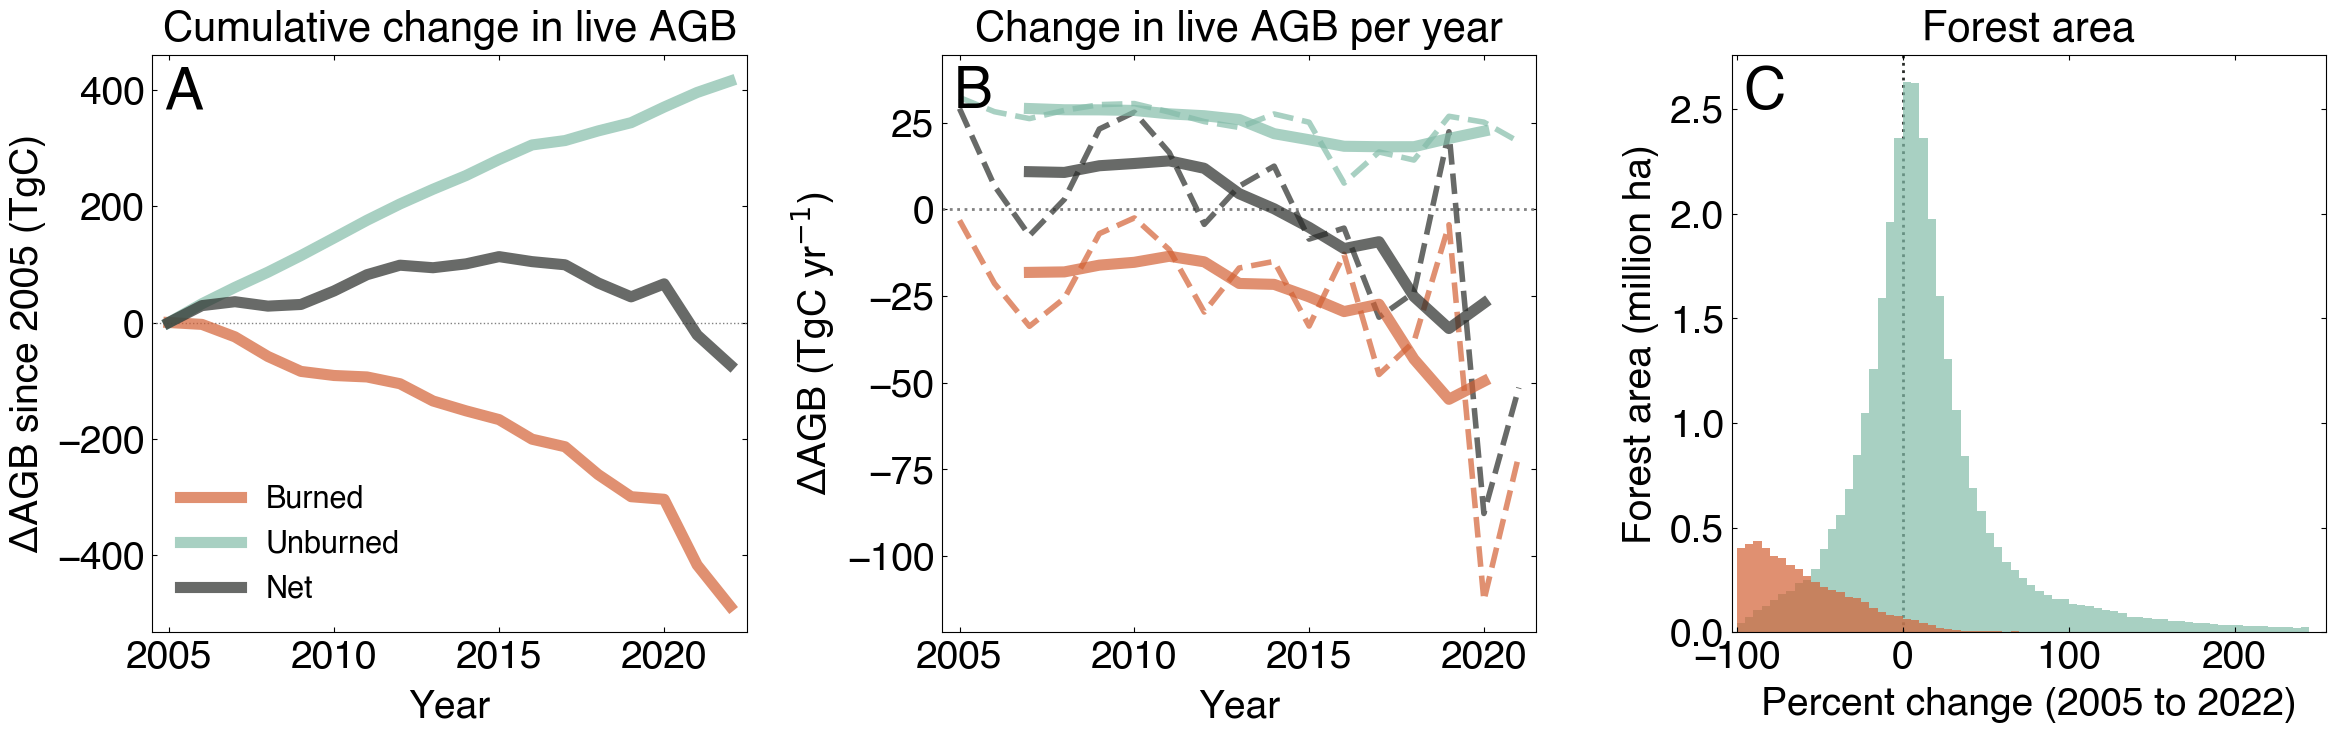

In [4]:
fig = plt.figure(figsize=(24, 8))


figure_settings.apply_style()

# Create axes with width ratios: left panel smaller, right panel bigger
gs = fig.add_gridspec(1, 3)  # , width_ratios=[1, 1, 1], wspace=0.15)
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])]

# Left plot - time series
ax = axes[1]

ax.set_ylabel("ΔAGB (TgC yr$^{-1}$)")
# ax.spines[["right", "top"]].set_visible(False)
ax.legend(frameon=False)
ax.set_xlim([2004.5, 2021.5])
ax.set_ylim([-122, 44.5])
ax.set_xticks(range(2005, 2025, 5))
ax.axhline(
    y=0,
    linestyle=":",
    color="gray",
    linewidth=style_settings["lines.linewidth"] / 4,
)

ax.plot(
    years[:-1],
    fire_losses_west[:-1],
    linewidth=style_settings["lines.linewidth"] / 2,
    linestyle="--",
    color=figure_settings.color_burned,
    alpha=alpha,
)
ax.plot(
    years[:-1],
    unburned_gains_west[:-1],
    linewidth=style_settings["lines.linewidth"] / 2,
    linestyle="--",
    color=figure_settings.color_unburned,
    alpha=alpha,
)
ax.plot(
    years[:-1],
    net_changes[:-1],
    linewidth=style_settings["lines.linewidth"] / 2,
    linestyle="--",
    color=figure_settings.color_net,
    alpha=alpha,
)
rolling_avg = pd.Series(np.array(unburned_gains_west)).rolling(window=5, center=True).mean()
ax.plot(
    years,
    rolling_avg,
    color=figure_settings.color_unburned,
    label="Unburned",
    linestyle="-",
    alpha=alpha,
)
rolling_avg = pd.Series(np.array(fire_losses_west)).rolling(window=5, center=True).mean()
ax.plot(
    years,
    rolling_avg,
    color=figure_settings.color_burned,
    label="Burned",
    linestyle="-",
    alpha=alpha,
)
rolling_avg = pd.Series(net_changes).rolling(window=5, center=True).mean()
ax.plot(
    years,
    rolling_avg,
    color=figure_settings.color_net,
    label="Net",
    linestyle="-",
    alpha=alpha,
)

ax.set_xlabel("Year", labelpad=10)
ax.set_title("Change in live AGB per year")

##############################################################################################################
##############################################################################################################

ax = axes[0]

ax.set_ylabel("ΔAGB since 2005 (TgC)")
# ax.spines[["right", "top"]].set_visible(False)
ax.legend(frameon=False)
ax.axhline(y=0, linestyle=":", color="gray", linewidth=1)

ax.plot(
    years,
    np.concatenate([[0], np.cumsum(fire_losses_west[:-1])]),
    # linewidth=8,
    color=figure_settings.color_burned,
    label="Burned",
    alpha=alpha,
)
ax.plot(
    years,
    np.concatenate([[0], np.cumsum(unburned_gains_west[:-1])]),
    # linewidth=8,
    color=figure_settings.color_unburned,
    label="Unburned",
    alpha=alpha,
)
ax.plot(
    years,
    np.concatenate([[0], np.cumsum(net_changes[:-1])]),
    # linewidth=8,
    color=figure_settings.color_net,
    label="Net",
    alpha=alpha,
)

ax.legend(frameon=False)
ax.set_xlim([2004.5, 2022.5])
ax.set_xlabel("Year", labelpad=10)
ax.set_title("Cumulative change in live AGB")

##############################################################################################################
##############################################################################################################
ax = axes[2]
counts_unburned, _, _ = ax.hist(
    delta_biomass_unburned.values.flatten() * 100,
    bins=np.arange(-100, 250, 5),
    alpha=alpha,
    density=False,
    color=figure_settings.color_unburned,
    label="Unburned",
    weights=(forest_area_ha.fillna(0).values.flatten()) / 1e6,
)
counts_burned, _, _ = ax.hist(
    delta_biomass_burned.values.flatten() * 100,
    bins=np.arange(-100, 250, 5),
    alpha=alpha,
    density=False,
    color=figure_settings.color_burned,
    label="Burned",
    weights=(forest_area_ha.fillna(0).values.flatten()) / 1e6,
)
ax.axvline(
    x=0,
    linestyle=":",
    linewidth=style_settings["lines.linewidth"] / 4,
    color=figure_settings.color_net,
    zorder=0,
)
ax.set_xlabel("Percent change (2005 to 2022)")
# ax.legend(framealpha=0)
ax.set_ylabel("Forest area (million ha)")
ax.set_title("Forest area")
ax.set_xlim([-103, 255])

labels = ["A", "B", "C"]
for i, ax in enumerate(axes):
    ax.text(
        figure_settings.panel_x_offset,
        figure_settings.panel_y_offset,
        labels[i],
        transform=ax.transAxes,
        fontsize=style_settings["font.size"] * 1.5,
        fontweight="bold",
        va="top",
    )

plt.tight_layout()
# fig.savefig(dir_info.dir_figures + "Figure3.jpg", bbox_inches="tight", dpi=300)
# fig.savefig(dir_info.dir_figures + "Figure3.pdf", bbox_inches="tight")
fig.savefig(dir_info.dir_figures + "fig-biomass_drivers.jpg", bbox_inches="tight", dpi=300)
fig.savefig(dir_info.dir_figures + "fig-biomass_drivers.pdf", bbox_inches="tight")